<a href="https://colab.research.google.com/github/JeyasriHariharan/Diamond-Dynamics-Price-Prediction-and-Market-Segmentation/blob/main/Diamond_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/diamonds.csv')

df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
print(df.shape)
print(df.columns)
df.info()

(53940, 11)
Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
print((df['x'] == 0).sum())
print((df['y'] == 0).sum())
print((df['z'] == 0).sum())

8
7
20


In [ ]:
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

df.shape

(53920, 11)

In [ ]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [ ]:
df = df.drop('Unnamed: 0', axis=1)

df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [ ]:
df.shape

(53920, 10)

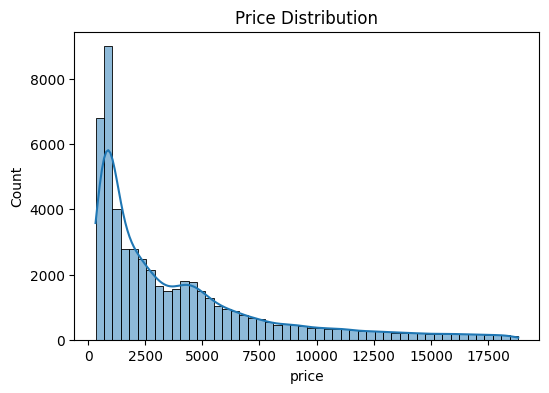

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

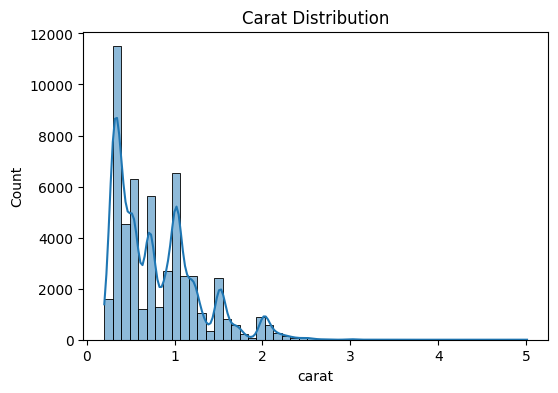

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['carat'], bins=50, kde=True)
plt.title("Carat Distribution")
plt.show()

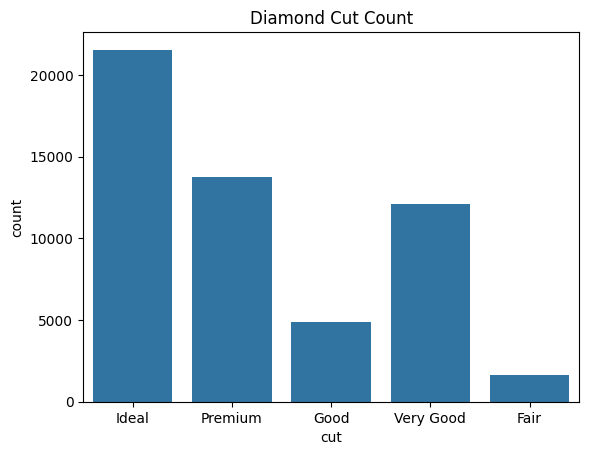

In [ ]:
sns.countplot(x='cut', data=df)
plt.title("Diamond Cut Count")
plt.show()

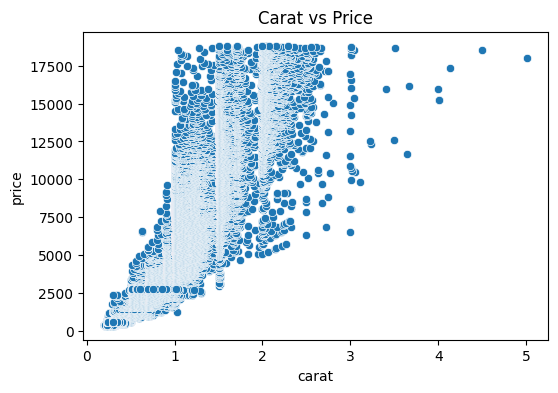

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='carat', y='price', data=df)
plt.title("Carat vs Price")
plt.show()

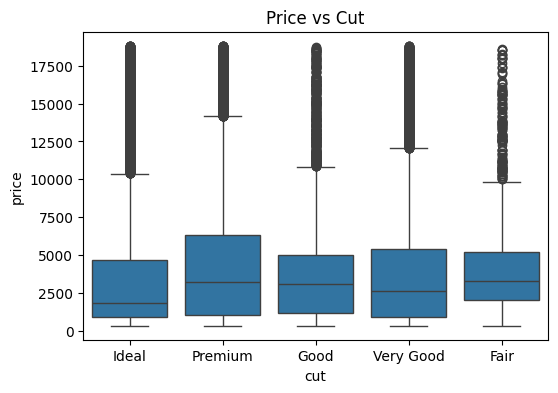

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='cut', y='price', data=df)
plt.title("Price vs Cut")
plt.show()

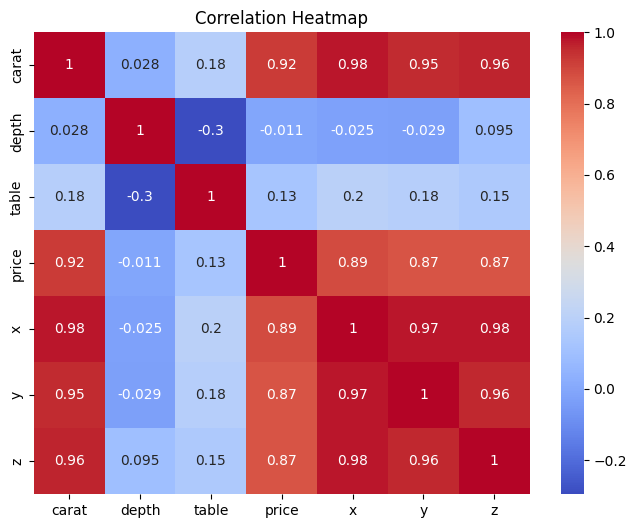

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

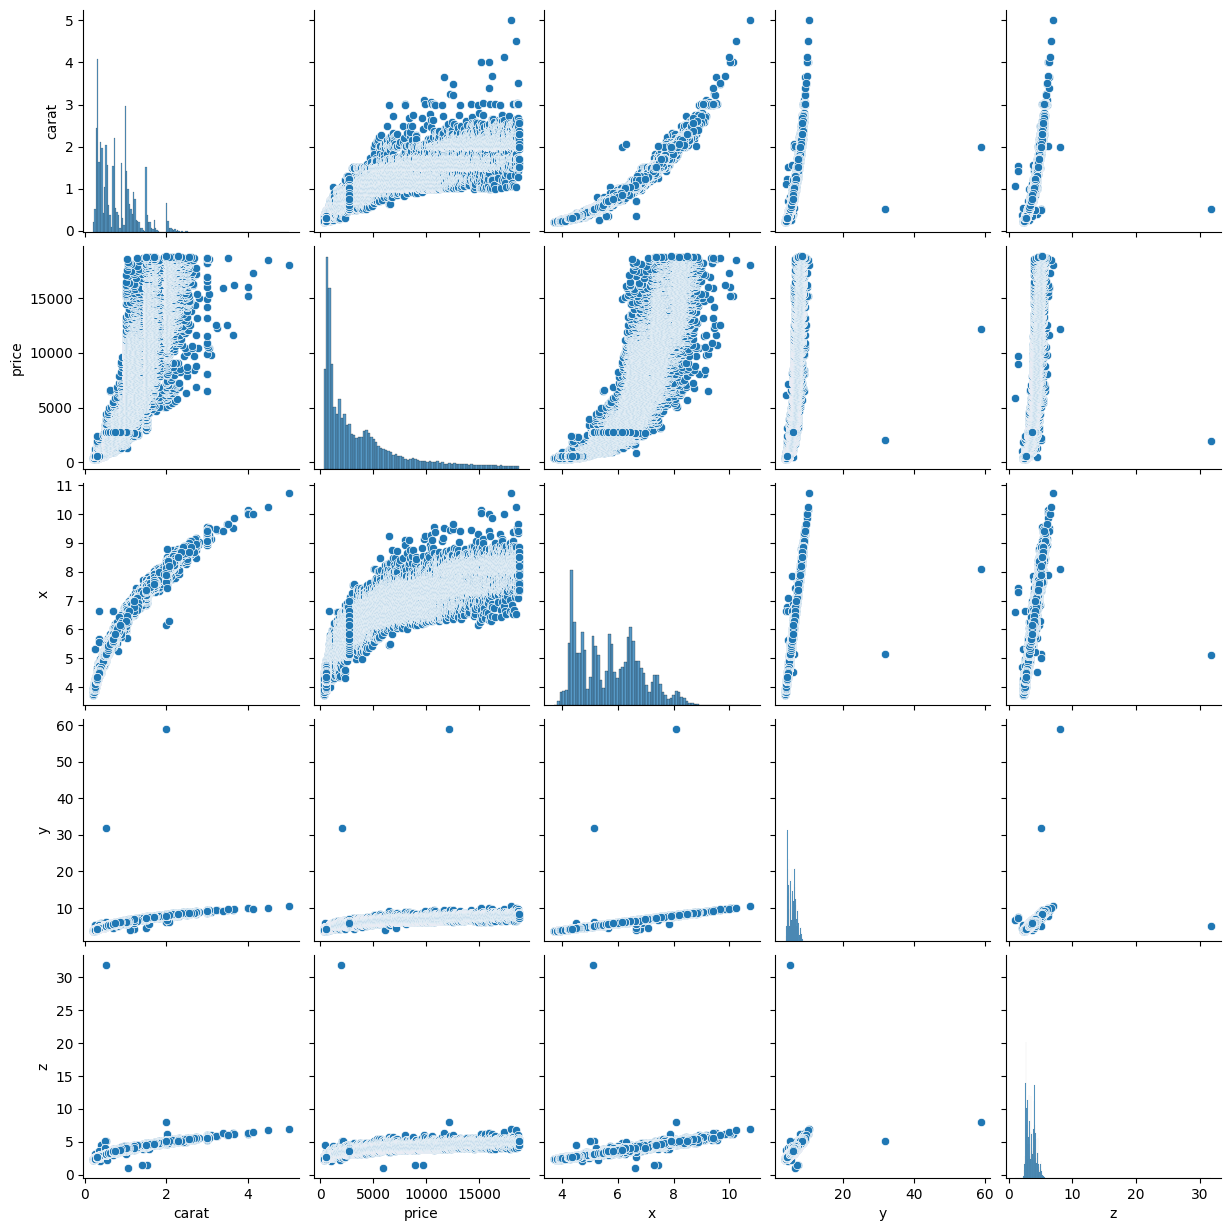

In [ ]:
sns.pairplot(df[['carat','price','x','y','z']])

In [ ]:
# Volume of diamond
df['volume'] = df['x'] * df['y'] * df['z']

# Price per carat
df['price_per_carat'] = df['price'] / df['carat']

# Dimension ratio
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

In [ ]:
def carat_category(carat):
    if carat < 0.5:
        return 'Light'
    elif carat <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

In [ ]:
# Convert USD to INR (approx rate)
df['price_inr'] = df['price'] * 83

In [ ]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volume,price_per_carat,dimension_ratio,carat_category,price_inr
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030,1417.391304,1.631687,Light,27058
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856,1552.380952,1.673160,Light,27058
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885,1421.739130,1.757576,Light,27141
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580,1151.724138,1.602662,Light,27722
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250,1080.645161,1.580000,Light,27805


In [ ]:
df.shape

(53920, 15)

In [ ]:
##ENCODING
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.head()

,carat,depth,table,price,x,y,z,volume,price_per_carat,dimension_ratio,...,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,carat_category_Light,carat_category_Medium
0,0.23,61.5,55.0,326,3.95,3.98,2.43,38.202030,1417.391304,1.631687,...,False,False,False,True,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,34.505856,1552.380952,1.673160,...,False,False,True,False,False,False,False,False,True,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,38.076885,1421.739130,1.757576,...,False,False,False,False,True,False,False,False,True,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,46.724580,1151.724138,1.602662,...,False,False,False,False,False,True,False,False,True,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,51.917250,1080.645161,1.580000,...,True,False,False,True,False,False,False,False,True,False


In [ ]:
##STEP 25: TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['price', 'price_inr', 'price_per_carat'], axis=1)
y = df_encoded['price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
##MODEL BUILDING
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
##PREDICTION
y_pred = model.predict(X_test)

In [ ]:
##EVALUATION
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 9850911994.345892
R2 Score: 0.9108063613606907


R² = 0.91

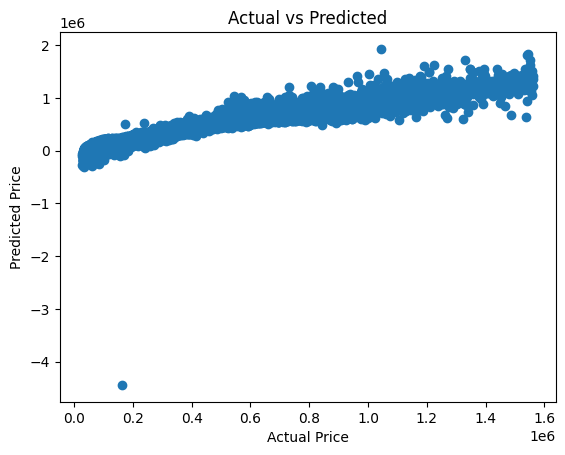

In [ ]:
###VISUALIZE PREDICTION
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

X-axis = Actual Price (real value)
Y-axis = Predicted Price (model output)

In [ ]:
##CLUSTERING (K-Means)
cluster_df = df[['carat','x','y','z','depth','table']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

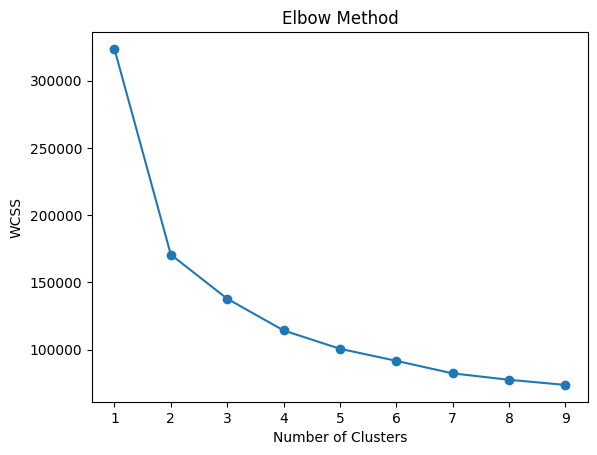

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

In [ ]:
df[['carat','price','cluster']].head()

,carat,price,cluster
0,0.23,326,1
1,0.21,326,1
2,0.23,327,1
3,0.29,334,1
4,0.31,335,1


In [ ]:
df.groupby('cluster')[['carat','price']].mean()

,carat,price
cluster,,
0,1.713508,11697.415505
1,0.400005,1053.625586
2,0.946712,4637.219716


In [ ]:
def cluster_name(cluster):
    if cluster == 0:
        return "Affordable Diamonds"
    elif cluster == 1:
        return "Mid-range Diamonds"
    else:
        return "Premium Diamonds"

df['cluster_name'] = df['cluster'].apply(cluster_name)

In [ ]:
df[['carat','price','cluster','cluster_name']].head()

,carat,price,cluster,cluster_name
0,0.23,326,1,Mid-range Diamonds
1,0.21,326,1,Mid-range Diamonds
2,0.23,327,1,Mid-range Diamonds
3,0.29,334,1,Mid-range Diamonds
4,0.31,335,1,Mid-range Diamonds


This project successfully analyzed and predicted diamond prices using machine learning techniques. After performing data cleaning and feature engineering, important variables such as carat, dimensions (x, y, z), volume, and categorical features like cut, color, and clarity were used to build the model.

The analysis showed that:

Carat (weight) has the strongest impact on price.
Diamond dimensions and volume significantly influence pricing.
Quality features like cut, color, and clarity also contribute to price variation.
Higher quality diamonds generally result in higher prices.

A Random Forest Regressor model was implemented, which provided stable and realistic predictions compared to linear models. The model was further integrated into a Streamlit application, allowing users to input diamond features and receive real-time price predictions.

Overall, this project demonstrates the application of data preprocessing, feature engineering, and machine learning to solve a real-world business problem.